In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [134]:
data = pd.read_csv("housing.csv", sep=",")

In [135]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [137]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [138]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

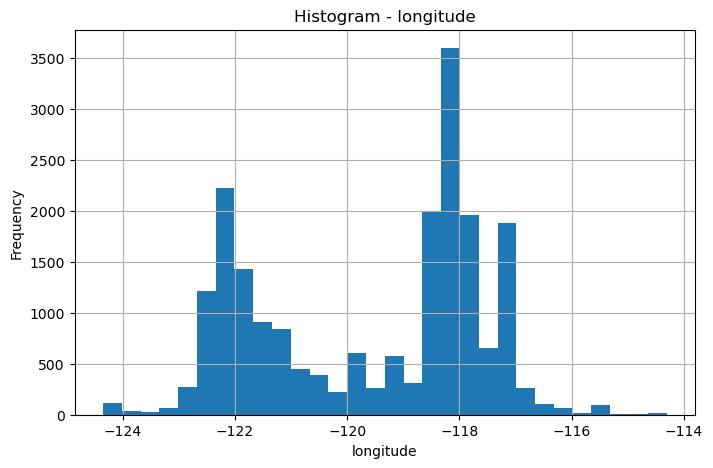

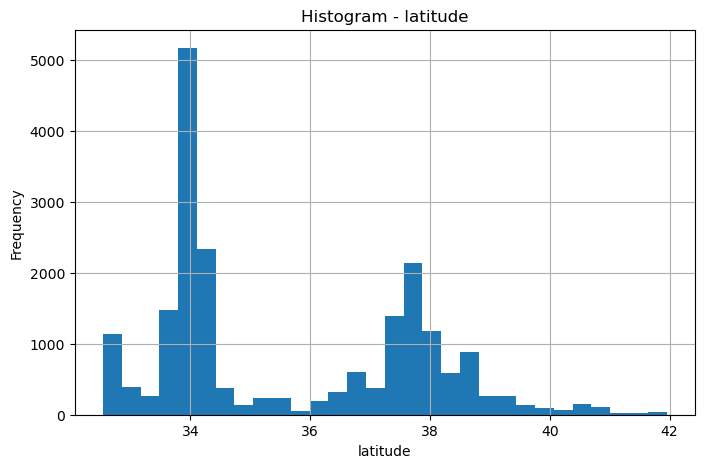

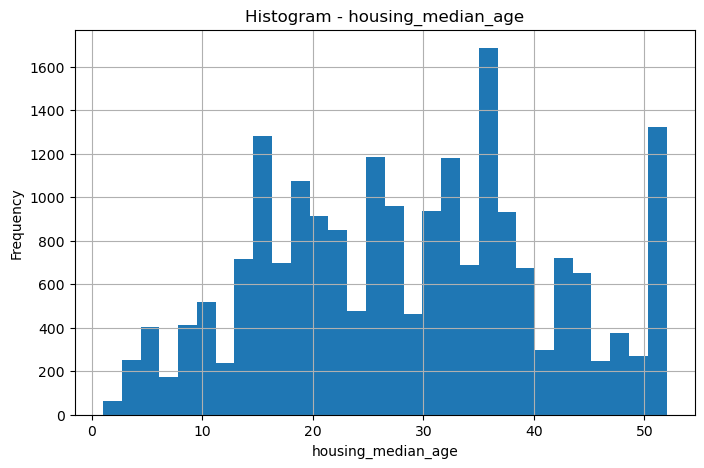

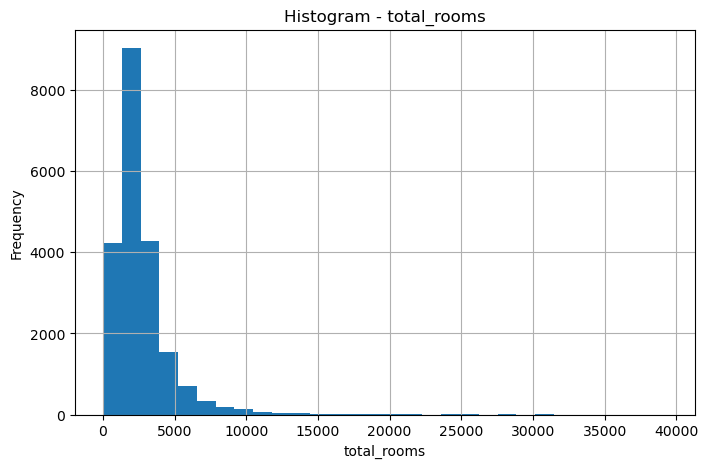

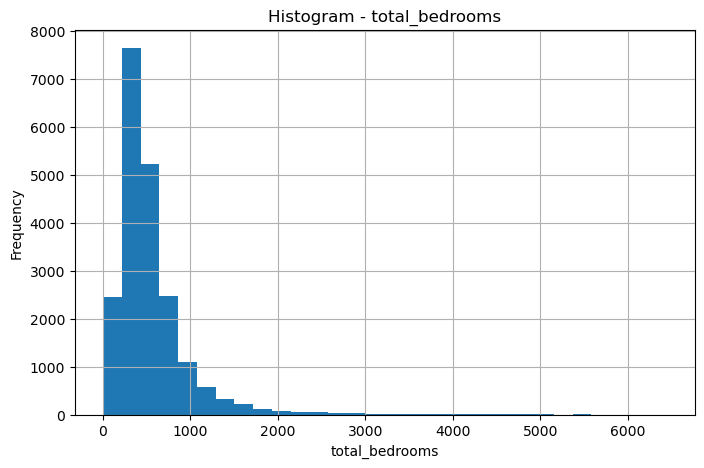

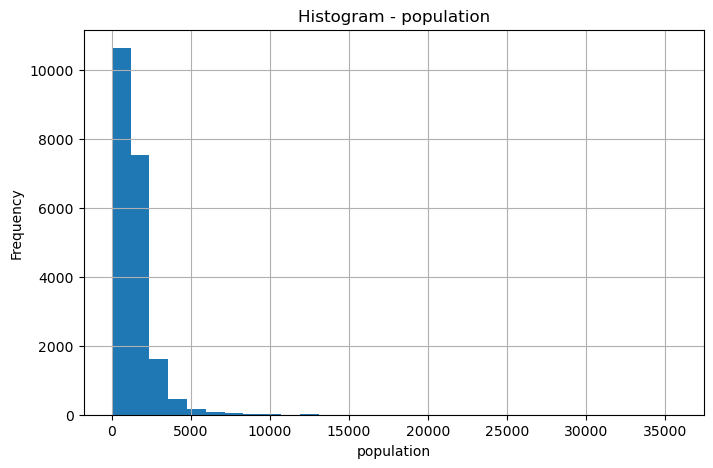

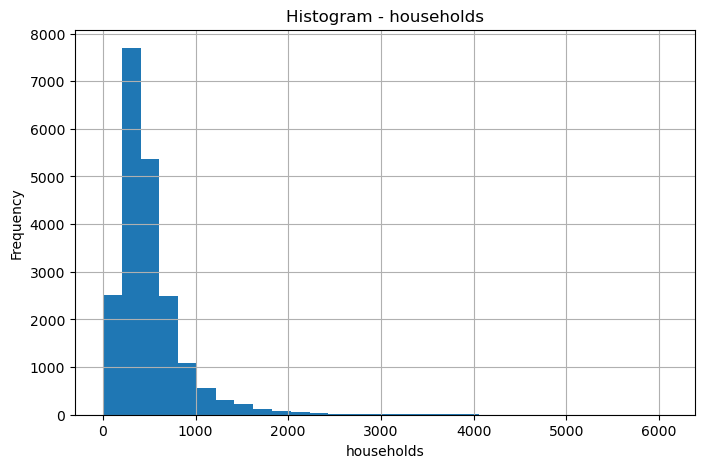

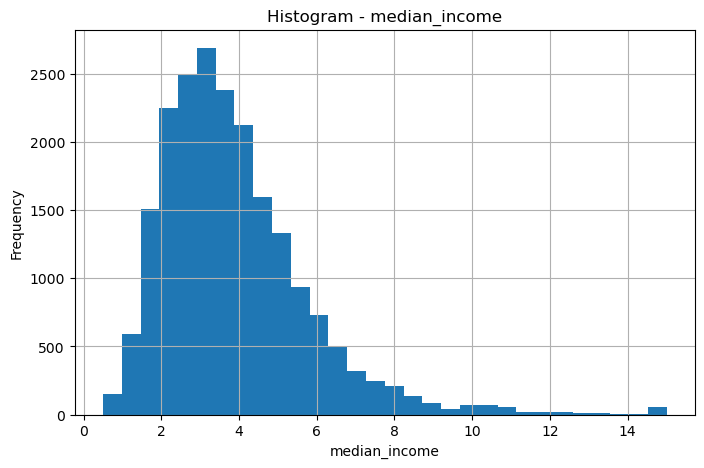

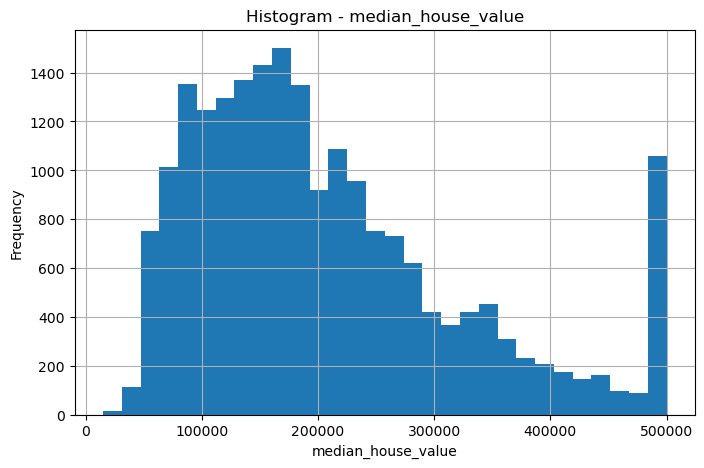

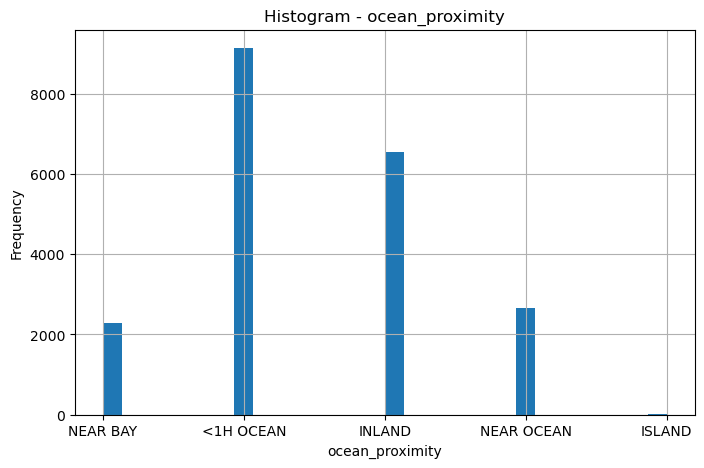

In [139]:
for c in data.columns:
    data[c].hist(figsize=(8,5), bins=30)
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

In [140]:
numeric_data = [c for c in data.columns if pd.api.types.is_numeric_dtype(data[c]) == True]

print(numeric_data)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


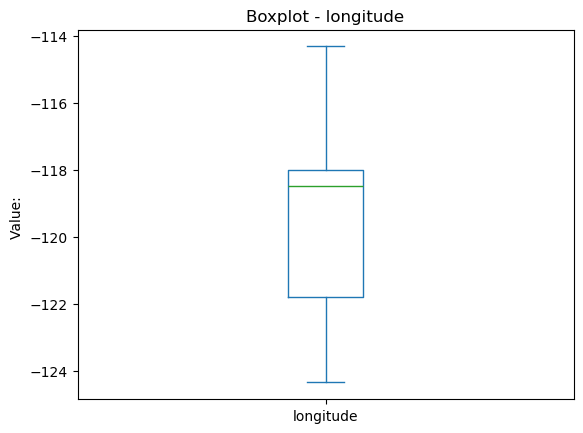

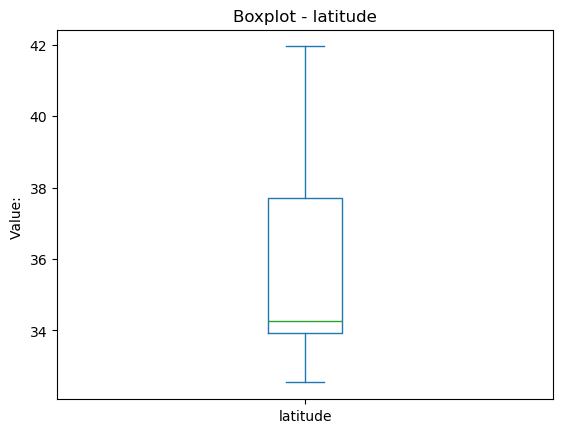

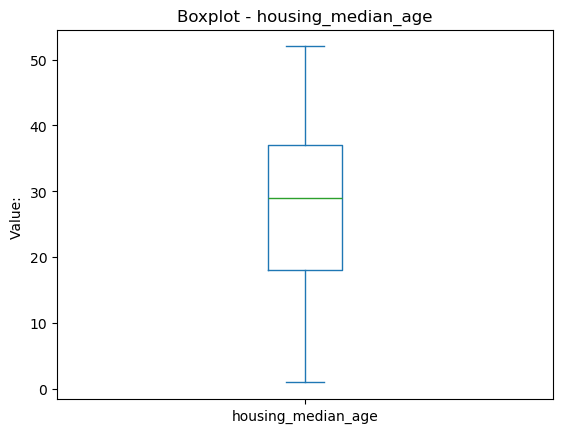

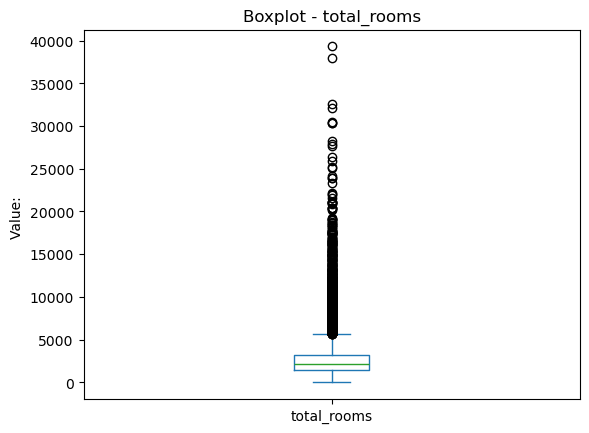

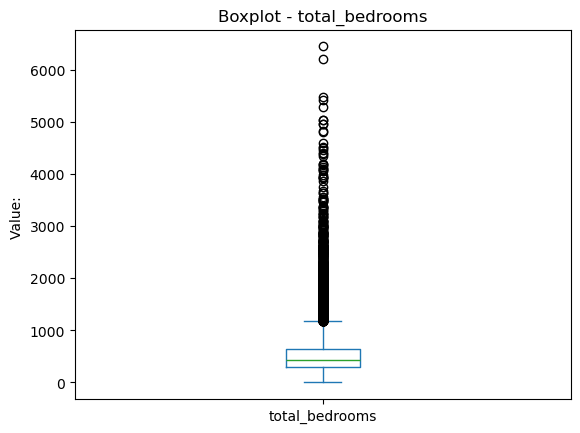

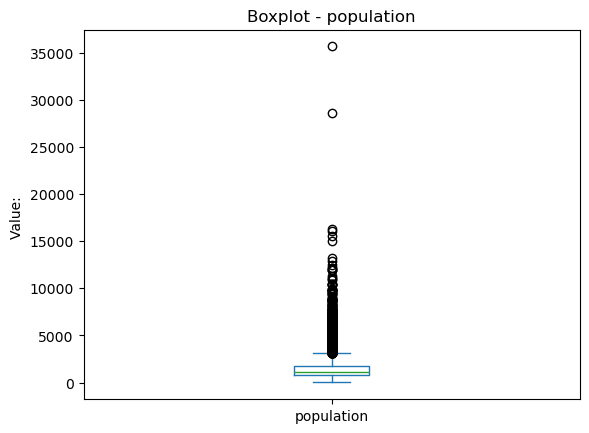

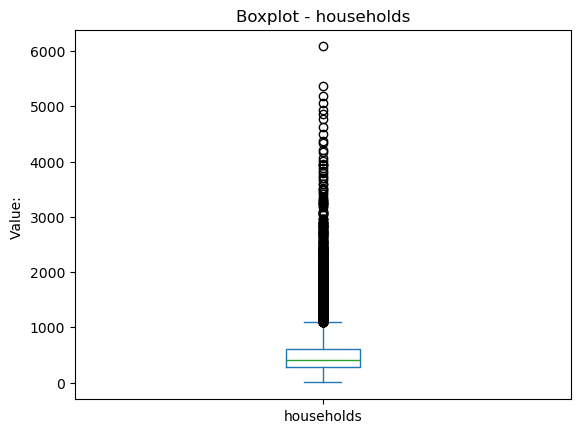

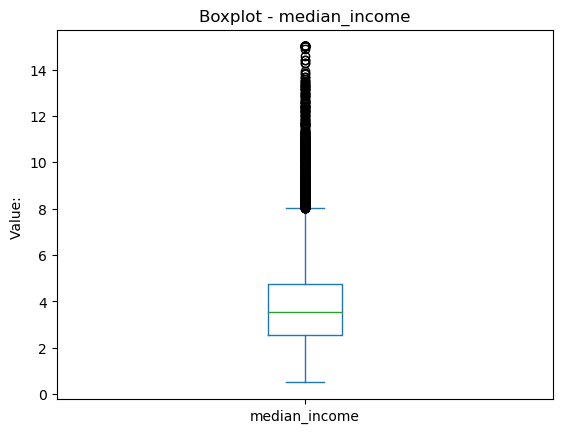

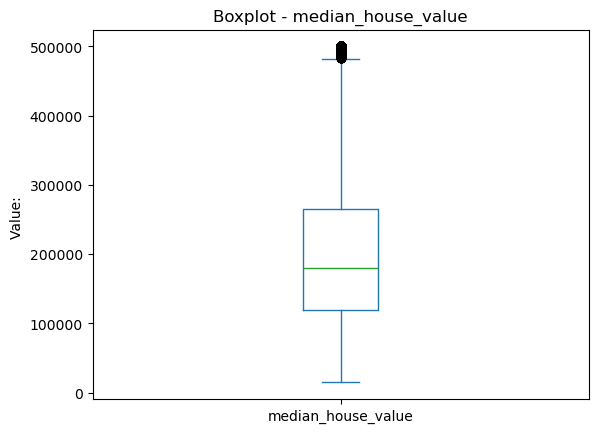

In [141]:
for c in numeric_data:
    data[c].plot(kind = "box")
    plt.title(f"Boxplot - {c}")
    plt.ylabel("Value: ")
    plt.show()

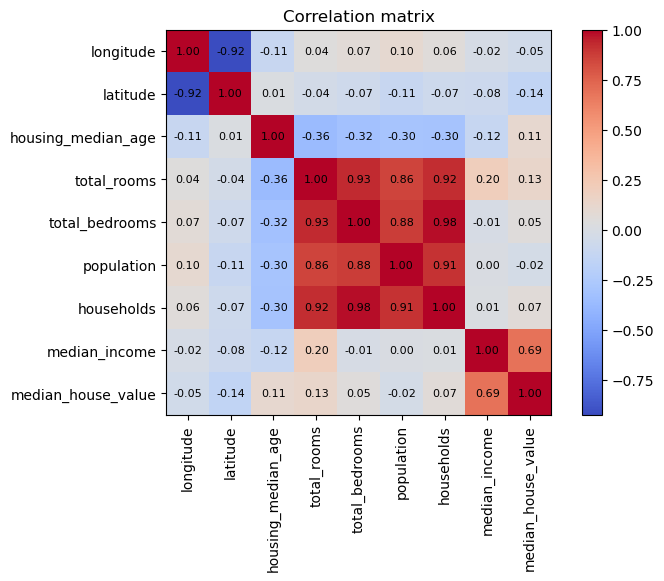

In [142]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(8,5))
plt.imshow(corr, interpolation="nearest", cmap="coolwarm")
plt.colorbar()

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", fontsize = 8, ha = "center", va = "center", color = "black")

plt.title("Correlation matrix")
plt.xticks(range(len(numeric_data)), numeric_data, rotation = 90)
plt.yticks(range(len(numeric_data)), numeric_data)
plt.show()

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [144]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

In [145]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [146]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [147]:
encoded_cols = encoder.fit_transform(data[["ocean_proximity"]])
encoded_df = pd.DataFrame(
    encoded_cols.toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"])
)
encoded_df.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [148]:
data = data.drop("ocean_proximity", axis = 1)

In [149]:
data = pd.concat([data, encoded_df], axis=1)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [150]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  float64
 10  ocean_proximity_INLAND      20640 non-null  float64
 11  ocean_proximity_ISLAND      20640 non-null  float64
 12  ocean_proximity_NEAR BAY    20640 non-null  float64
 13  ocean_proximity_NEAR OCEAN  206

In [151]:
data["room_per_households"] = (data["total_rooms"] / data["households"]) 
data["bedrooms_per_room"] = (data["total_bedrooms"] / data["total_rooms"]) 
data["population_per_household"] = (data["population"] / data["households"])

In [152]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


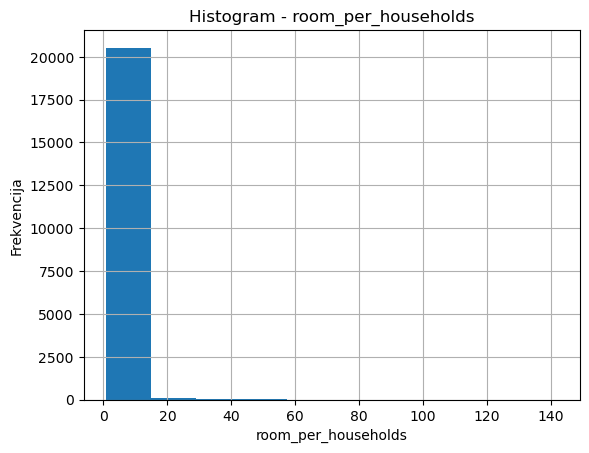

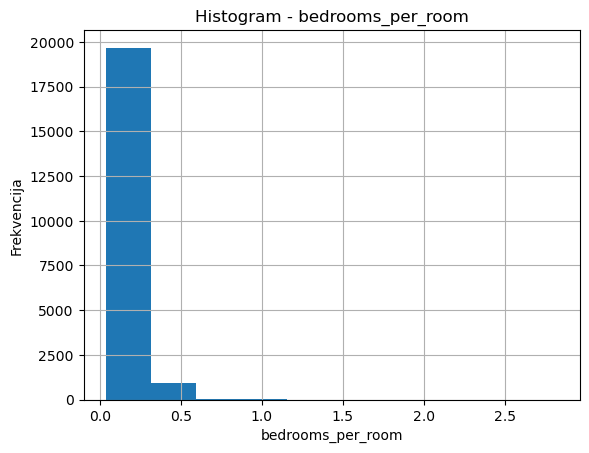

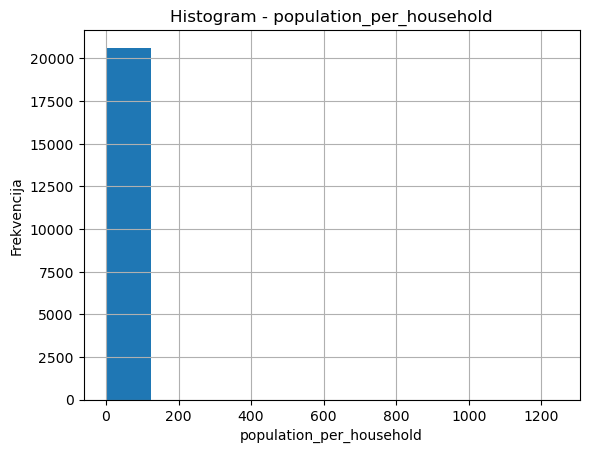

In [153]:
new_features = ["room_per_households", "bedrooms_per_room", "population_per_household"]
for c in new_features:
    data[c].hist()
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Frekvencija")
    plt.show()

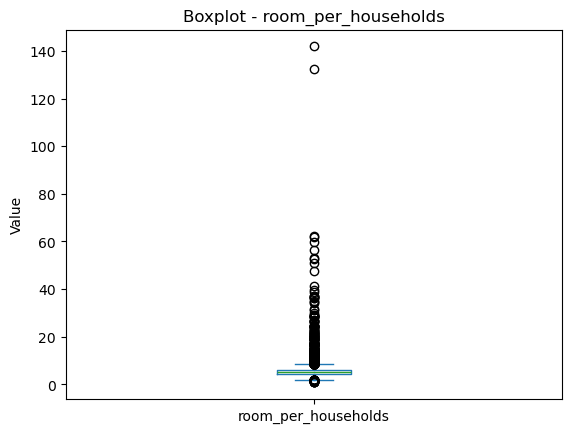

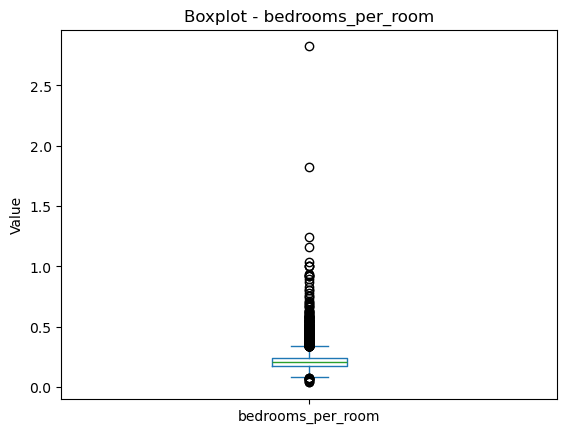

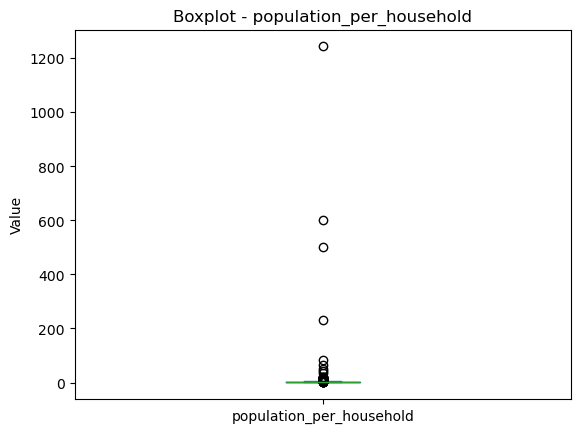

In [154]:
for c in new_features:
    data[c].plot(kind="box")
    plt.title(f"Boxplot - {c}")
    plt.ylabel("Value")
    plt.show()

In [155]:
data.sort_values("room_per_households", ascending=False).head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
1914,-120.10,38.91,33.0,1561.0,282.0,30.0,11.0,1.8750,500001.0,0.0,1.0,0.0,0.0,0.0,141.909091,0.180653,2.727273
1979,-120.08,38.80,34.0,1988.0,511.0,36.0,15.0,4.6250,162500.0,0.0,1.0,0.0,0.0,0.0,132.533333,0.257042,2.400000
12447,-114.49,33.97,17.0,2809.0,635.0,83.0,45.0,1.6154,87500.0,0.0,1.0,0.0,0.0,0.0,62.422222,0.226059,1.844444
1913,-120.06,39.01,19.0,2967.0,528.0,112.0,48.0,4.0714,437500.0,0.0,1.0,0.0,0.0,0.0,61.812500,0.177958,2.333333
11862,-121.25,40.27,25.0,958.0,245.0,28.0,16.0,2.6250,67500.0,0.0,1.0,0.0,0.0,0.0,59.875000,0.255741,1.750000
1912,-120.16,39.01,16.0,1463.0,264.0,54.0,26.0,4.9750,206300.0,0.0,1.0,0.0,0.0,0.0,56.269231,0.180451,2.076923
9676,-119.02,37.64,14.0,5919.0,1278.0,265.0,112.0,3.2431,221400.0,0.0,1.0,0.0,0.0,0.0,52.848214,0.215915,2.366071
11707,-120.06,39.15,22.0,2213.0,372.0,98.0,42.0,1.1912,170000.0,0.0,1.0,0.0,0.0,0.0,52.690476,0.168098,2.333333
2395,-119.34,37.12,23.0,1881.0,380.0,64.0,37.0,3.8750,125000.0,0.0,1.0,0.0,0.0,0.0,50.837838,0.202020,1.729730
1240,-120.19,38.42,11.0,1568.0,369.0,82.0,33.0,3.1250,77500.0,0.0,1.0,0.0,0.0,0.0,47.515152,0.235332,2.484848


In [156]:
data["room_per_households"].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: room_per_households, dtype: float64

In [157]:
data_log = pd.DataFrame()

for c in new_features:
    data_log[f"{c}_log"] = np.log1p(data[c])

data_log.head(10)

,room_per_households_log,bedrooms_per_room_log,population_per_household_log
0,2.077455,0.136793,1.268511
1,1.979364,0.144790,1.134572
2,2.228738,0.121789,1.335596
3,1.919471,0.169286,1.266369
4,1.985385,0.158793,1.157342
5,1.751225,0.208455,1.144190
6,1.780346,0.176387,1.140523
7,1.757431,0.199938,1.025415
8,1.666596,0.231329,1.107536
9,1.786845,0.181664,1.154447


In [158]:
data_log.describe().T

,count,mean,std,min,25%,50%,75%,max
room_per_households_log,20640.0,1.828722,0.231938,0.613104,1.693911,1.829236,1.953365,4.962209
bedrooms_per_room_log,20640.0,0.192486,0.049034,0.036477,0.161459,0.184951,0.215213,1.341474
population_per_household_log,20640.0,1.351645,0.207530,0.526093,1.232485,1.339757,1.454481,7.126355


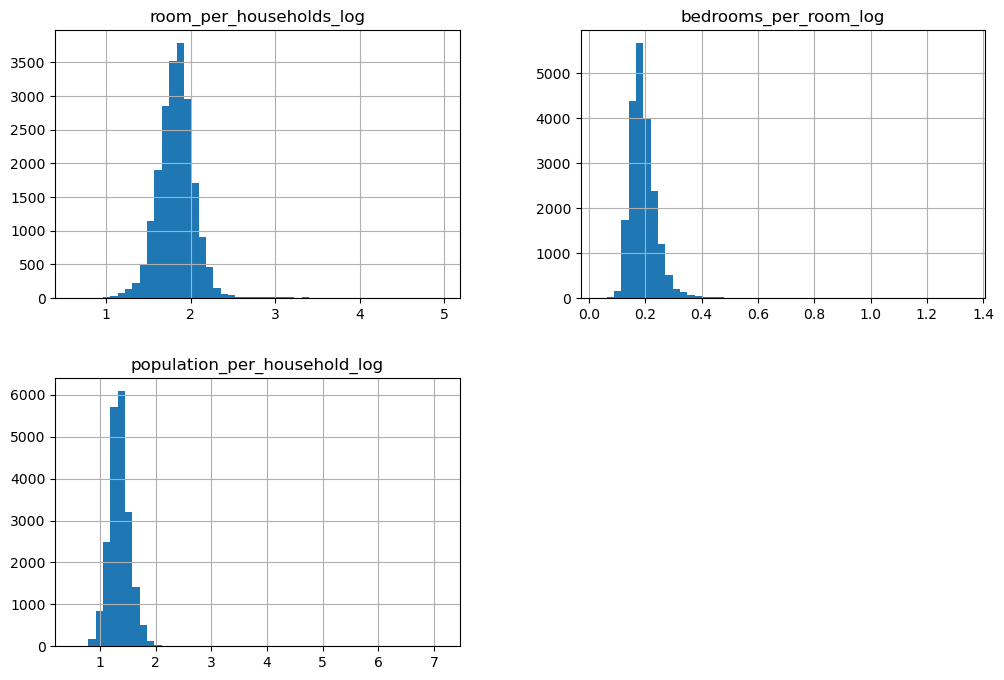

In [159]:
data_log[[c for c in data_log.columns]].hist(bins=50, figsize=(12,8))
plt.show()

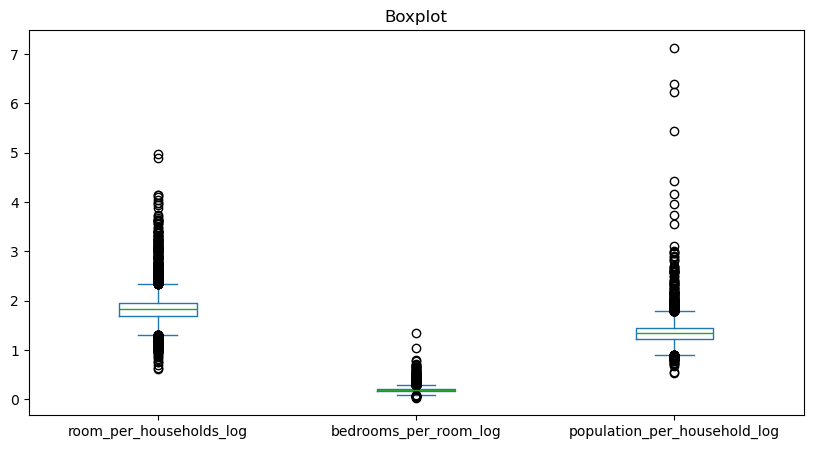

In [160]:
data_log[[c for c in data_log.columns]].plot(kind="box", figsize=(10,5))
plt.title("Boxplot")
plt.show()

In [161]:
df_model = data.copy()
df_model.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


In [162]:
df_model = df_model.drop(["room_per_households", "bedrooms_per_room", "population_per_household"], axis = 1)
df_model = pd.concat([df_model, data_log], axis=1)

In [163]:
df_model.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households_log,bedrooms_per_room_log,population_per_household_log
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,2.077455,0.136793,1.268511
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,1.979364,0.144790,1.134572
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,2.228738,0.121789,1.335596
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,1.919471,0.169286,1.266369
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,1.985385,0.158793,1.157342


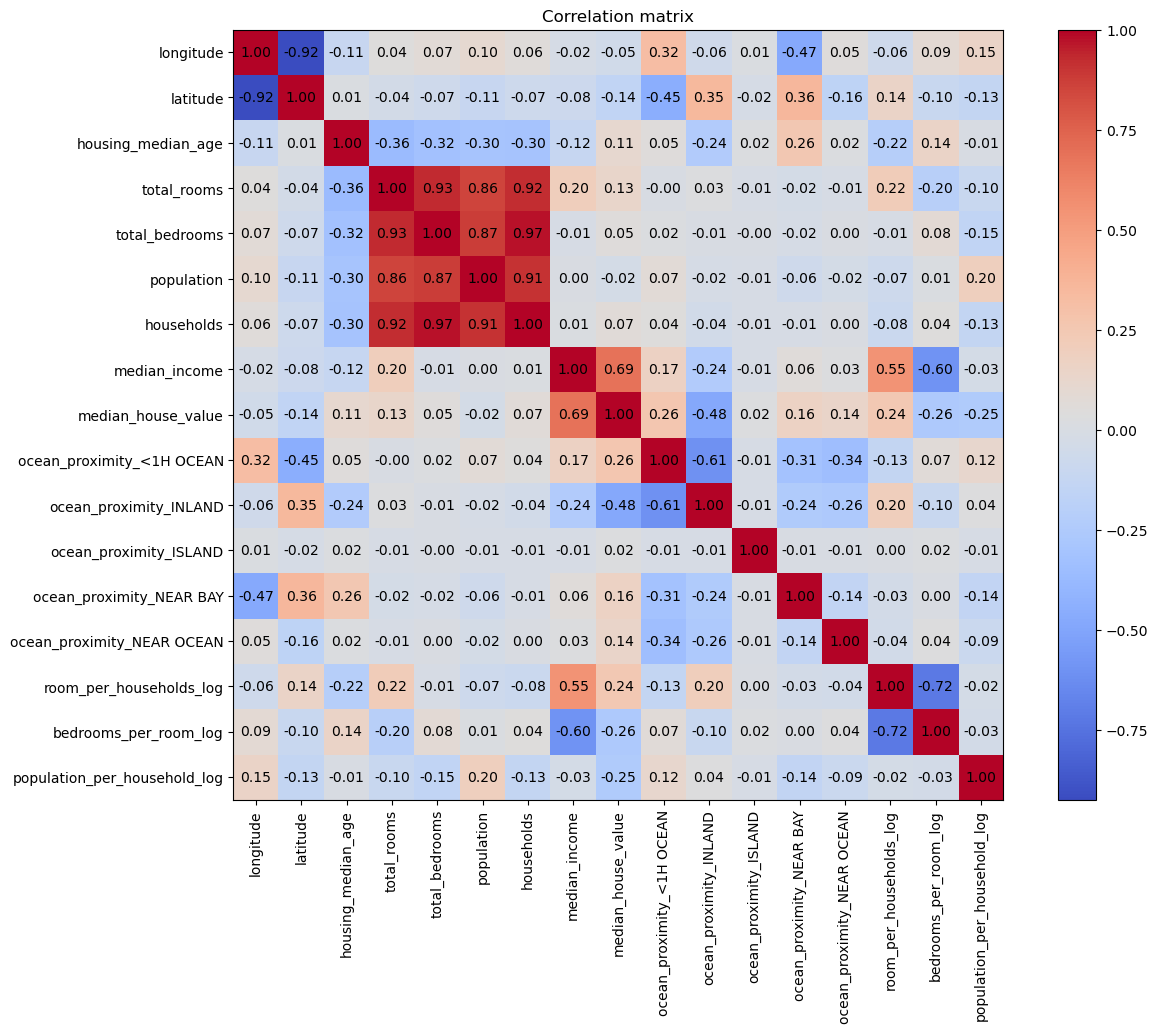

In [164]:
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(14,10))

plt.xticks(range(len(corr.columns)), corr.columns, rotation = 90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha = "center", va = "center")

plt.imshow(corr, interpolation="nearest", cmap="coolwarm")
plt.colorbar()
plt.title("Correlation matrix")
plt.show()


In [165]:
X = df_model.drop("median_house_value", axis = 1)
y = df_model["median_house_value"]

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [168]:
scaler = StandardScaler()
model = LinearRegression()

In [169]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [170]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [171]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 49925.49
MSE: 5002720370.03
RMSE: 70729.91
R2: 0.62


In [172]:
results = pd.DataFrame(
    {
    "Predicted": y_pred,
    "Actual": y_test
    }
)

results["Predicted"] = results["Predicted"].astype(float).round(2)
results["Actual"] = results["Actual"].astype(float).round(2)

results.sort_index().head(10)

,Predicted,Actual
0,412740.73,452600.0
3,324374.51,341300.0
6,257732.86,299200.0
17,198444.03,155500.0
19,204510.80,162900.0
31,181604.30,115200.0
34,221265.52,109700.0
35,171343.84,97200.0
41,196363.23,150000.0
42,151965.54,118800.0


In [173]:
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state=42)

In [174]:
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [175]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = mse_tree ** 0.5
r2_tree = r2_score(y_test, y_pred_tree)

print(f"MAE: {mae_tree}")
print(f"MSE: {mse_tree}")
print(f"RMSE: {rmse_tree}")
print(f"R2: {r2_tree}")

MAE: 44426.25411821705
MSE: 5341986207.068071
RMSE: 73088.89250131015
R2: 0.5923420629917246


In [176]:
results_tree = pd.DataFrame(
    {
        "Predicted": y_pred_tree,
        "Actual": y_test
    }
)

results_tree["Actual - Predicted"] = results_tree["Actual"] - results_tree["Predicted"]

results_tree["Predicted"] = results_tree["Predicted"].astype(float).round(2)

results_tree.sort_values(by="Actual - Predicted", ascending=False).head(10)

,Predicted,Actual,Actual - Predicted
14463,77100.0,500001.0,422901.0
12389,90000.0,500001.0,410001.0
10574,90300.0,500001.0,409701.0
6688,98800.0,500001.0,401201.0
15614,100000.0,500001.0,400001.0
459,137500.0,500001.0,362501.0
5354,157000.0,500001.0,343001.0
4265,112500.0,450000.0,337500.0
9421,144600.0,478600.0,334000.0
12220,168700.0,500001.0,331301.0


In [177]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [178]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [179]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf}")
print(f"MSE: {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R2: {r2_rf}")

MAE: 32314.84199370155
MSE: 2538273991.2722836
RMSE: 50381.286121657155
R2: 0.806299099485744


In [180]:
result_rf = pd.DataFrame(
    {
        "Predicted": y_pred_rf,
        "Actual": y_test
    }
)

result_rf["Actual - Predicted"] = result_rf["Actual"] - result_rf["Predicted"]
result_rf["Predicted"] = result_rf["Predicted"].astype(float).round(2)

result_rf.head(10)

,Predicted,Actual,Actual - Predicted
20046,48622.00,47700.0,-922.00
3024,111471.00,45800.0,-65671.00
15663,465645.47,500001.0,34355.53
20484,269010.00,218600.0,-50410.00
9814,233220.00,278000.0,44780.00
13311,192803.00,158700.0,-34103.00
7113,266475.08,198200.0,-68275.08
7668,164496.00,157500.0,-6996.00
18246,250465.02,340000.0,89534.98
5723,480121.75,446600.0,-33521.75


In [181]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(random_state=42)

In [182]:
X_train = X_train.rename(columns={"ocean_proximity_<1H OCEAN":"ocean_proximity_1H OCEAN"})

X_test = X_test.rename(columns={"ocean_proximity_<1H OCEAN":"ocean_proximity_1H OCEAN"})

In [183]:
xgb_model.fit(X_train, y_train)
y_predict_xgb = xgb_model.predict(X_test)

In [184]:
mae_xgb = mean_absolute_error(y_test, y_predict_xgb)
mse_xgb = mean_squared_error(y_test, y_predict_xgb)
rmse_xgb = mse_xgb ** 0.5
r2_xgb = r2_score(y_test, y_predict_xgb)

print(f"MAE: {mae_xgb}")
print(f"MSE: {mse_xgb}")
print(f"RMSE: {rmse_xgb}")
print(f"R2: {r2_xgb}")


MAE: 30587.40569642533
MSE: 2185089387.905794
RMSE: 46744.939703734715
R2: 0.8332513418185619


In [185]:
result_df = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
        "MAE": [mae, mae_tree, mae_rf, mae_xgb],
        "RMSE": [rmse, rmse_tree, rmse_rf, rmse_xgb],
        "R2": [r2, r2_tree, r2_rf, r2_xgb]
    }
)

result_df = result_df.round(3)
result_df.head(10)

,Model,MAE,RMSE,R2
0,Linear Regression,49925.486,70729.911,0.618
1,Decision Tree,44426.254,73088.893,0.592
2,Random Forest,32314.842,50381.286,0.806
3,XGBoost,30587.406,46744.940,0.833


In [186]:
from sklearn.model_selection import RandomizedSearchCV

In [187]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

search_xgb = RandomizedSearchCV(
    estimator = XGBRegressor(random_state = 42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42
)

search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [188]:
print(search_xgb.best_params_)

{'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}


In [189]:
best_model = search_xgb.best_estimator_
y_pred_xgb_best = best_model.predict(X_test)

mae_xgb_best = mean_absolute_error(y_test, y_pred_xgb_best)
mse_xgb_best = mean_squared_error(y_test, y_pred_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
r2_xgb_best = r2_score(y_test, y_pred_xgb_best)

print(f"MAE: {mae_xgb_best}")
print(f"MSE: {mse_xgb_best}")
print(f"RMSE: {rmse_xgb_best}")
print(f"R2: {r2_xgb_best}")

MAE: 30526.698281931323
MSE: 2128885540.4742897
RMSE: 46139.84764251275
R2: 0.8375403728283275


In [190]:
result_df.loc[len(result_df)] = [
    "XGBoost (optimized)",
    mae_xgb_best,
    rmse_xgb_best,
    r2_xgb_best
]

result_df = result_df.round(3)
result_df.head(10)

,Model,MAE,RMSE,R2
0,Linear Regression,49925.486,70729.911,0.618
1,Decision Tree,44426.254,73088.893,0.592
2,Random Forest,32314.842,50381.286,0.806
3,XGBoost,30587.406,46744.940,0.833
4,XGBoost (optimized),30526.698,46139.848,0.838


In [191]:
importance = best_model.feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature: ": X_train.columns,
        "Importance": importance
    }
)

importance_df.head(10)

,Feature:,Importance
0,longitude,0.023654
1,latitude,0.021309
2,housing_median_age,0.024637
3,total_rooms,0.006886
4,total_bedrooms,0.008139
5,population,0.005859
6,households,0.007974
7,median_income,0.235189
8,ocean_proximity_1H OCEAN,0.009053
9,ocean_proximity_INLAND,0.518960
